In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
file_2 = "../data/summary_data_proofs/03.geo_score_data_2026.csv"

data3 = pd.read_csv(file_2)



structure_hits_filtered = pd.read_csv("../data/summary_data_proofs/02.structure_hits_filtered_muts.csv")

# geo data must remove the mutations that are not in the structure hits filtered data
data3 = data3.query("uid in @structure_hits_filtered.uid")
print(len(data3))

print(len(data3), len(data3["ks_test_num_significant_0p01"].dropna()), len(data3["distance_top_pair"].dropna()))


3606
3606 3592 3590


In [9]:
# Reported number of proteins in structure plus homoplasy dataset: 3687
# Twelve tier-one proteins tested for significance, eight found
# 499 significant hits, 452 significant hits within 15 angstrom threshold

In [10]:
def compute_numbers_for_paper(df, ks_thresh = 9267.0, distance_thresh = 15):
    print("total number of data points", len(df))
    print("Number of hits with significant ks test", len(df[df["ks_test_num_significant_0p01"] > ks_thresh]))
    print("Number of hits within distance threshold", len(df[np.logical_and(df["distance_top_pair"] < distance_thresh,df["ks_test_num_significant_0p01"] > ks_thresh)]))
    print("Percent of hits within distance threshold", len(df[np.logical_and(df["distance_top_pair"] < distance_thresh,df["ks_test_num_significant_0p01"] > ks_thresh)])    /len(df[df["ks_test_num_significant_0p01"] > ks_thresh]))
    n_hits = len(df[np.logical_and(df["distance_top_pair"] < distance_thresh,df["ks_test_num_significant_0p01"] > ks_thresh)])
    return n_hits


compute_numbers_for_paper(data3, distance_thresh=5)
compute_numbers_for_paper(data3, distance_thresh=8)
compute_numbers_for_paper(data3, distance_thresh=12)
compute_numbers_for_paper(data3, distance_thresh=15)

total number of data points 3606
Number of hits with significant ks test 499
Number of hits within distance threshold 305
Percent of hits within distance threshold 0.6112224448897795
total number of data points 3606
Number of hits with significant ks test 499
Number of hits within distance threshold 373
Percent of hits within distance threshold 0.7474949899799599
total number of data points 3606
Number of hits with significant ks test 499
Number of hits within distance threshold 423
Percent of hits within distance threshold 0.8476953907815631
total number of data points 3606
Number of hits with significant ks test 499
Number of hits within distance threshold 452
Percent of hits within distance threshold 0.905811623246493


452

Distance threshold 2
total number of data points 3606
Number of hits with significant ks test 499
Number of hits within distance threshold 162
Percent of hits within distance threshold 0.3246492985971944
total number of data points 3606
Number of hits with significant ks test 3590
Number of hits within distance threshold 1204
Percent of hits within distance threshold 0.3353760445682451
Distance threshold 3
total number of data points 3606
Number of hits with significant ks test 499
Number of hits within distance threshold 184
Percent of hits within distance threshold 0.3687374749498998
total number of data points 3606
Number of hits with significant ks test 3590
Number of hits within distance threshold 1351
Percent of hits within distance threshold 0.37632311977715877
Distance threshold 4
total number of data points 3606
Number of hits with significant ks test 499
Number of hits within distance threshold 279
Percent of hits within distance threshold 0.5591182364729459
total number of d

FileNotFoundError: [Errno 2] No such file or directory: '/Users/annagreen/Desktop/CICS_local/Green_mutation_clustering_local/codebase/MTB_Mut_Clust/figures/number_of_hits_as_function_of_distance_threshold.pdf'

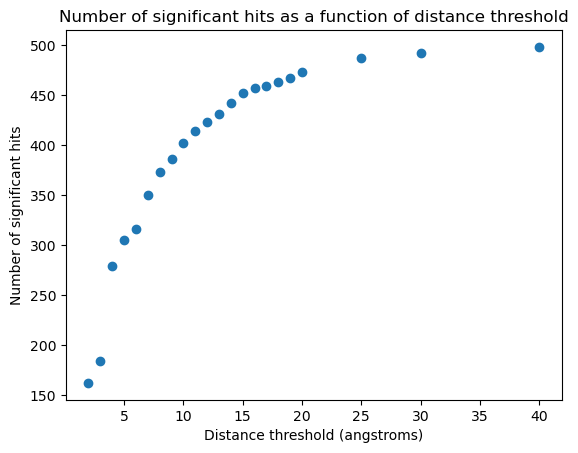

In [11]:
# Make a plot of number of hits as a function of distance threshold. 
thresh_list = [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,25,30,40]
for_plotting = []
for_plotting_2 = []

for distance_thresh in thresh_list:
   
    print("Distance threshold", distance_thresh)
    num_hits = compute_numbers_for_paper(data3, ks_thresh = 9267.0, distance_thresh = distance_thresh)
    for_plotting_2.append(compute_numbers_for_paper(data3, ks_thresh = 0, distance_thresh = distance_thresh))

    for_plotting.append(num_hits)

plt.scatter(x=thresh_list, y=for_plotting)
#plt.scatter(x=thresh_list, y=for_plotting_2)
plt.xlabel("Distance threshold (angstroms)")
plt.ylabel("Number of significant hits")
plt.title("Number of significant hits as a function of distance threshold")
plt.savefig("/Users/annagreen/Desktop/CICS_local/Green_mutation_clustering_local/codebase/MTB_Mut_Clust/figures/number_of_hits_as_function_of_distance_threshold.pdf")


Text(0.5, 1.0, 'Number of significant hits as a function of distance threshold')

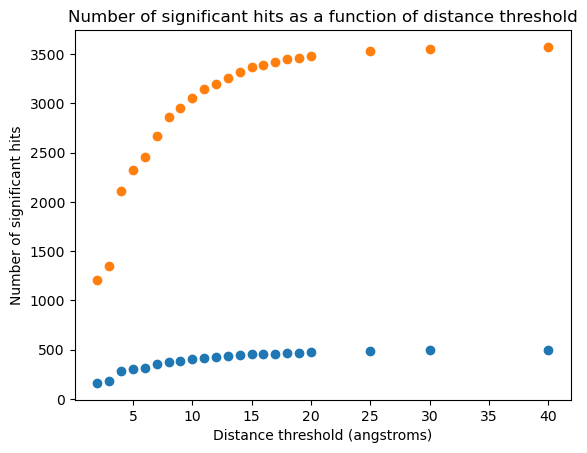

In [12]:
plt.scatter(x=thresh_list, y=for_plotting)
plt.scatter(x=thresh_list, y=for_plotting_2)
plt.xlabel("Distance threshold (angstroms)")
plt.ylabel("Number of significant hits")
plt.title("Number of significant hits as a function of distance threshold")

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        filtered_length   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     3.919
Date:                Fri, 22 May 2026   Prob (F-statistic):             0.0483
Time:                        10:07:50   Log-Likelihood:                -3480.5
No. Observations:                 499   AIC:                             6965.
Df Residuals:                     497   BIC:                             6973.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               497.4636     15.442     32.215      0.000     467.124     527.803
distance_top_pair    -3.1806      1.607     -1.980      0.048      -6.337      -0.024
==============================================================================
Omnibus:                      140.536   Durbin-Watson:                   1.962
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              313.961
Skew:                           1.479   Prob(JB):                     6.67e-69
Kurtosis:                       5.520   Cond. No.                         12.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

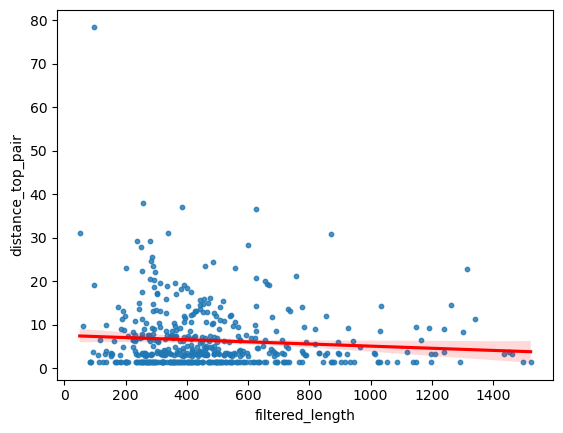

In [32]:
#sns.kdeplot(x=data3.filtered_length, y=data3.distance_top_pair, cmap="Blues", fill=True)

#Add a regression line between distance and filtered length
# print the coefficient and p-value for the regression
ks_thresh = 9267.0

data3_cleaned = data3.dropna(subset=["filtered_length", "distance_top_pair"])
data3_cleaned = data3_cleaned[data3_cleaned["ks_test_num_significant_0p01"] > ks_thresh]
sns.regplot(x=data3_cleaned.filtered_length, y=data3_cleaned.distance_top_pair, scatter=True, scatter_kws={"s": 10}, line_kws={"color": "red"}, )
import statsmodels.api as sm
plt.savefig("/Users/annagreen/Desktop/CICS_local/Green_mutation_clustering_local/codebase/MTB_Mut_Clust/figures/length_vs_distance_top_pair.pdf")

sm.OLS(data3_cleaned.filtered_length, sm.add_constant(data3_cleaned.distance_top_pair)).fit().summary()


In [33]:
sm.__version__

'0.14.4'

In [26]:
data3_cleaned.sort_values("distance_top_pair", ascending=False)

,Unnamed: 0,uid,Entry,rv,set,pdb_id,pdb_chain,filtered_length,num_shuffles,max_pvalue,min_pvalue,median_pvalue,ks_test_num_significant_0p01,max_GeO,selected_pvalue,total_mutations,max_mutations,distance_top_pair
2612,2666,SECE_MYCTU,P9WGN7,Rv0638,setA,NaN,NaN,60.0,10000.0,0.999486,2.549988e-04,0.377731,203.0,2.693654,0.513012,28.0,3.0,81.092468
228,232,Y3067_MYCTU,I6YB21,Rv3067,setA,NaN,NaN,96.0,10000.0,0.795570,2.854608e-11,0.000002,9439.0,6.053917,0.012693,33.0,8.0,78.541542
2834,2893,RS11_MYCTU,P9WH65,Rv3459c,setA,NaN,NaN,119.0,10000.0,0.998316,2.563445e-08,0.006676,5293.0,3.130007,0.691700,33.0,3.0,59.337547
3049,3119,CRGA_MYCTU,P9WP57,Rv0011c,setA,NaN,NaN,39.0,10000.0,1.000000,1.620278e-08,0.388766,557.0,1.722675,0.752262,20.0,3.0,58.558868
3255,3328,I6XYM2_MYCTU,I6XYM2,Rv1677,setA,NaN,NaN,136.0,10000.0,0.999446,1.441414e-08,0.028764,3313.0,3.110955,0.006149,87.0,4.0,57.578026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1925,1968,Q79FJ0_MYCTU,Q79FJ0,Rv1888A,setB,6id6,A,55.0,10000.0,0.999999,2.557347e-04,0.610223,26.0,2.771599,0.610223,27.0,3.0,1.310702
2177,2223,P94978_MYCTU,P94978,Rv1644,setB,5kzk,A,241.0,10000.0,0.999402,2.202880e-13,0.047681,3271.0,2.963848,0.028453,111.0,3.0,1.310315
1841,1884,I6WZS8_MYCTU,I6WZS8,Rv0926c,setB,6g1h,A,326.0,10000.0,0.925152,1.870429e-17,0.000014,8626.0,3.529594,0.037466,141.0,3.0,1.309605
2008,2052,O53407_MYCTU,O53407,Rv1059,setB,6g1h,A,319.0,10000.0,0.999967,2.126257e-15,0.080677,2780.0,3.423071,0.000292,166.0,4.0,1.309605


<Axes: xlabel='ks_test_num_significant_0p01', ylabel='distance_top_pair'>

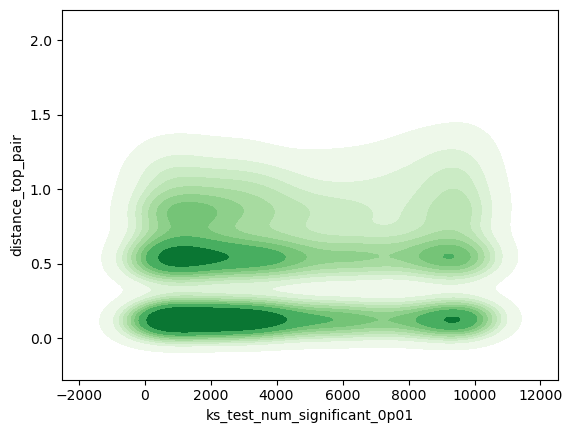

In [8]:
sns.kdeplot(x=data3.ks_test_num_significant_0p01, y=np.log10(data3.distance_top_pair), cmap="Greens", fill=True)

In [9]:
data3.sort_values(["ks_test_num_significant_0p01", "distance_top_pair"], ascending=[False, True]).head(50)

,Unnamed: 0,uid,Entry,rv,set,pdb_id,pdb_chain,filtered_length,num_shuffles,max_pvalue,min_pvalue,median_pvalue,ks_test_num_significant_0p01,max_GeO,selected_pvalue,total_mutations,max_mutations,distance_top_pair
3187,3259,P71719_MYCTU,P71719,Rv2381c,setA,NaN,NaN,904.0,10000.0,8.829731e-03,1.292373e-55,3.490175e-20,10000.0,3.625023,5.322349e-22,287.0,5.0,1.325037
641,664,I6XEF1_MYCTU,I6XEF1,Rv2487c,setA,NaN,NaN,319.0,10000.0,7.740856e-04,1.389798e-79,2.854102e-48,10000.0,5.520133,1.193671e-61,28.0,3.0,1.325651
147,150,PG30_MYCTU,Q79FL8,Rv1651c,setA,NaN,NaN,572.0,10000.0,2.298731e-52,5.365847e-63,3.801505e-61,10000.0,8.390017,3.801505e-61,138.0,5.0,1.328848
1740,1781,GLGB_MYCTU,P9WN45,Rv1326c,setB,3k1d,A,721.0,10000.0,3.936020e-03,2.912004e-64,2.069217e-28,10000.0,4.070969,9.806824e-46,202.0,4.0,1.329010
30,31,Y1702_MYCTU,P9WLT3,Rv1702c,setA,NaN,NaN,354.0,10000.0,2.586586e-05,2.851425e-29,5.510510e-20,10000.0,12.494063,3.215573e-15,138.0,10.0,1.330040
784,813,L0TCB8_MYCTU,L0TCB8,Rv3367,setA,NaN,NaN,435.0,10000.0,5.231498e-17,2.247475e-63,1.952033e-54,10000.0,6.984162,1.820390e-56,108.0,4.0,1.333225
61,64,Y1459_MYCTU,O53150,Rv1459c,setA,NaN,NaN,495.0,10000.0,1.301760e-04,4.064991e-41,4.017486e-22,10000.0,4.213425,4.017486e-22,124.0,3.0,1.335698
1151,1187,SYFA_MYCTU,P9WFU3,Rv1649,setB,6p24,C,322.0,10000.0,8.332786e-04,1.547991e-35,2.195428e-22,10000.0,4.074464,1.240392e-18,88.0,3.0,1.336172
3323,3397,P71815_MYCTU,P71815,Rv0758,setA,NaN,NaN,438.0,10000.0,9.109847e-04,9.244063e-21,7.170900e-15,10000.0,4.488217,7.023321e-12,803.0,20.0,1.337632
1293,1329,MASZ_MYCTU,P9WK17,Rv1837c,setB,5e9x,A,715.0,10000.0,2.393289e-08,1.091651e-106,1.474137e-57,10000.0,10.914327,4.669804e-73,286.0,9.0,1.341624


In [10]:
### Problems:
# - We report having applied the G-score test to 3687 proteins, but only 3404 ended up in our table. What happened to the missing ~250?
# - We reported 499 hits, only 452 wsithin 15 ang, but can't reproduce from our table
# - why is there a plateau at 15 angstroms?
# Suspicion: I accidentally filtered the 250 at some point based on their distance. Need to find them/ensure they are included in the table.

# Had used an older version of the file where the distances were filtered. Confirmed that there are 499 sig hits, 452 below the angstrom threshold
